In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

In [2]:
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')
print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)

Train shape: (421570, 5)
Stores shape: (45, 3)
Features shape: (8190, 12)


In [3]:
#merging the datasets
df=train.merge(stores, on='Store', how='left')
df=df.merge(features,on=['Store','Date'], how='left')


In [4]:
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values(by='Date')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
277665,29,5,2010-02-05,15552.08,False,B,93638,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False
277808,29,6,2010-02-05,3200.22,False,B,93638,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False
277951,29,7,2010-02-05,10820.05,False,B,93638,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False
278094,29,8,2010-02-05,20055.64,False,B,93638,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False


In [5]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (421570, 17)

Column names:
 ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y']

Data types:
 Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday_x               bool
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday_y               bool
dtype: object


In [6]:
df.drop(columns=['IsHoliday_y'], inplace=True)
df.rename(columns={'IsHoliday_x':'IsHoliday'}, inplace=True)

In [7]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage %': missing_pct
}).query('`Missing Values` > 0')
print(missing_df)


           Missing Values  Percentage %
MarkDown1          270889     64.257181
MarkDown2          310322     73.611025
MarkDown3          284479     67.480845
MarkDown4          286603     67.984676
MarkDown5          270138     64.079038


In [8]:
df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 
    'CPI', 'Unemployment']].describe()

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,15981.258123,60.090059,3.361027,171.201947,7.960289
std,22711.183519,18.447931,0.458515,39.159276,1.863296
min,-4988.940000,-2.060000,2.472000,126.064000,3.879000
25%,2079.650000,46.680000,2.933000,132.022667,6.891000
50%,7612.030000,62.090000,3.452000,182.318780,7.866000
75%,20205.852500,74.280000,3.738000,212.416993,8.572000
max,693099.360000,100.140000,4.468000,227.232807,14.313000


In [9]:
markdown_cols=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols]=df[markdown_cols].fillna(0)

In [10]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64

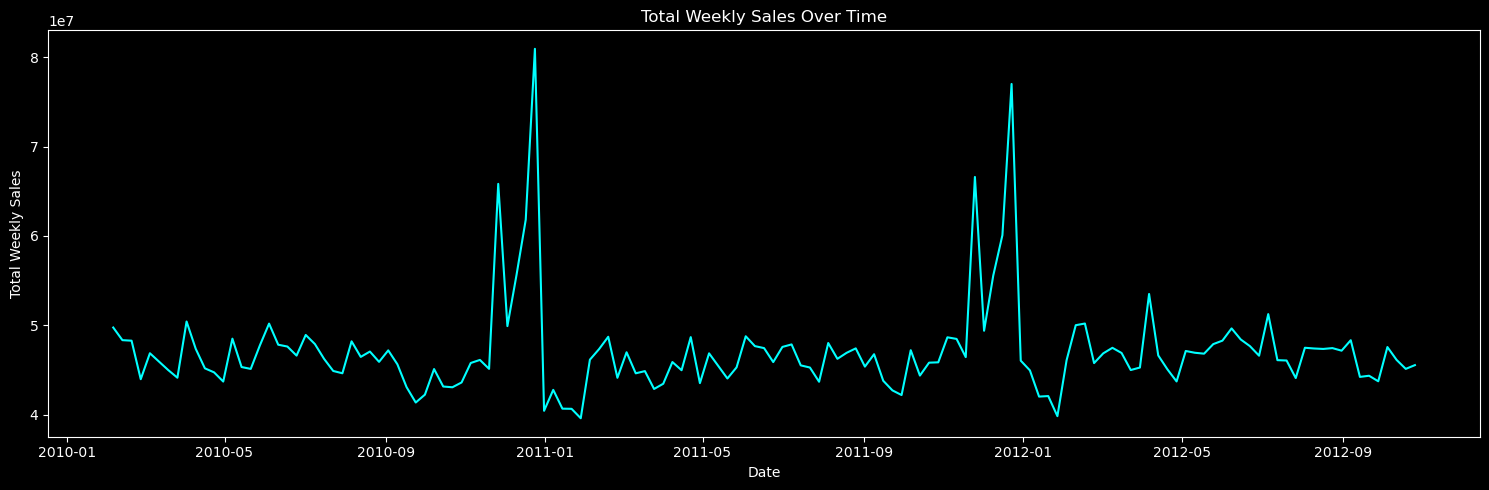

In [11]:
weekly=df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(15,5))
plt.plot(weekly['Date'], weekly['Weekly_Sales'],color='cyan')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.tight_layout()
plt.show()


C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\3136291816.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_sales , x='IsHoliday', y='Weekly_Sales', palette='viridis')


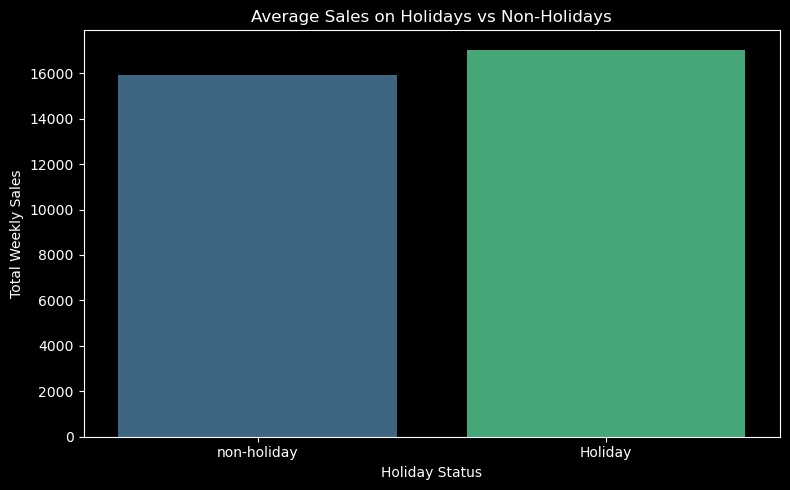

In [12]:
holiday_sales=df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()
holiday_sales['IsHoliday']=holiday_sales['IsHoliday'].map({True:'Holiday',False:'non-holiday'})

plt.figure(figsize=(8,5))
sns.barplot(data=holiday_sales , x='IsHoliday', y='Weekly_Sales', palette='viridis')
plt.title('Average Sales on Holidays vs Non-Holidays')
plt.xlabel('Holiday Status')
plt.ylabel('Total Weekly Sales')
plt.tight_layout()
plt.show()

C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\1402363422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_sales, x='Store', y='Weekly_Sales', palette='magma')


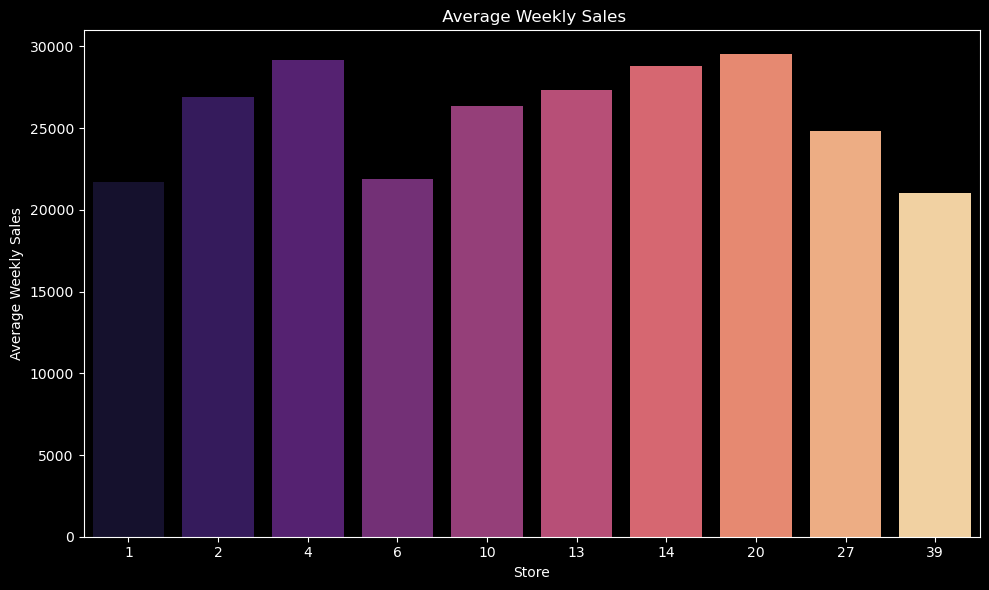

In [13]:
store_sales=df.groupby('Store')['Weekly_Sales'].mean().reset_index()
store_sales=store_sales.sort_values(by='Weekly_Sales', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=store_sales, x='Store', y='Weekly_Sales', palette='magma')
plt.title(' Average Weekly Sales')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\4145629283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=department_sales, x='Dept', y='Weekly_Sales', palette='plasma')


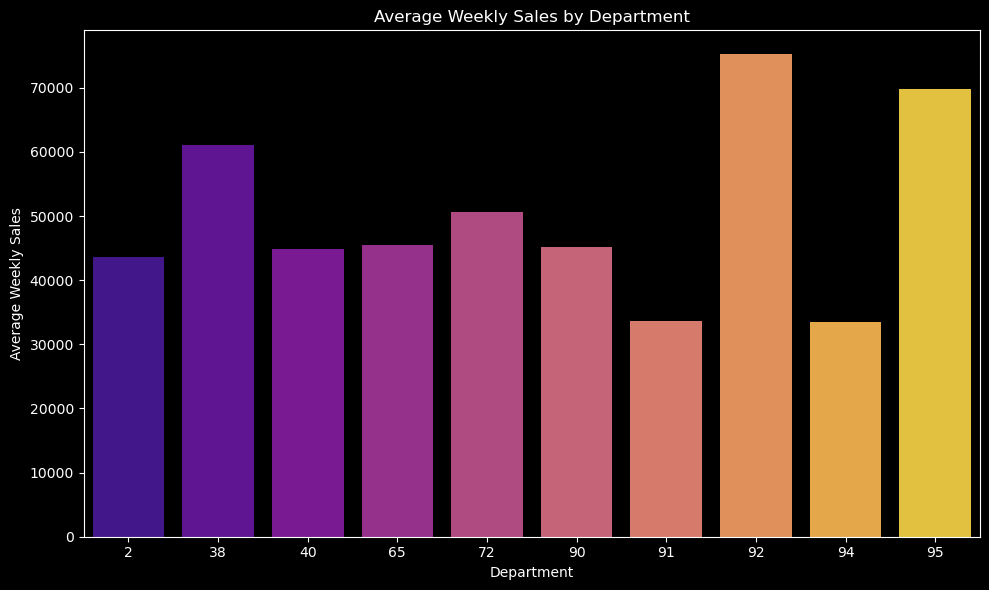

In [14]:
department_sales=df.groupby('Dept')['Weekly_Sales'].mean().reset_index()
department_sales=department_sales.sort_values(by='Weekly_Sales', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=department_sales, x='Dept', y='Weekly_Sales', palette='plasma')
plt.title('Average Weekly Sales by Department')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\3740052087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_sales, x='Type', y='Weekly_Sales', palette='coolwarm')


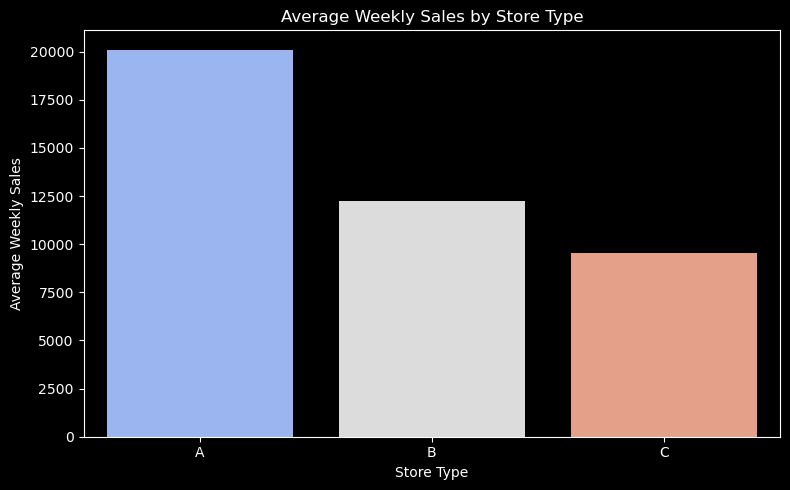

In [15]:
type_sales=df.groupby('Type')['Weekly_Sales'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=type_sales, x='Type', y='Weekly_Sales', palette='coolwarm')
plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

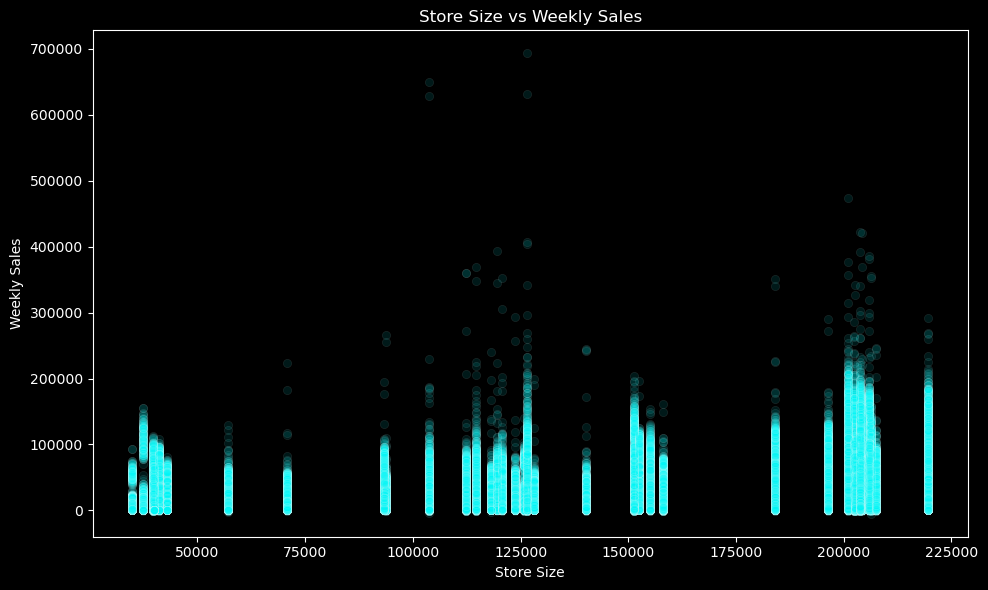

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Size', y='Weekly_Sales', alpha=0.1, color='cyan')
plt.title('Store Size vs Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()


## insights

sales Icreases in Holidays

Type A larger than B larger than c

the more size the more sales 

dept 95 ,92 are the highest sales



Time Series Decomposition

In [17]:
store1 = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum().reset_index()
store1.set_index('Date', inplace=True)
store1['Trend'] = store1['Weekly_Sales'].rolling(window=52, center=True).mean()
store1['seasonality'] = store1['Weekly_Sales'] - store1['Trend']
store1['residual'] = store1['Weekly_Sales'] - store1['Trend'] - store1['seasonality']


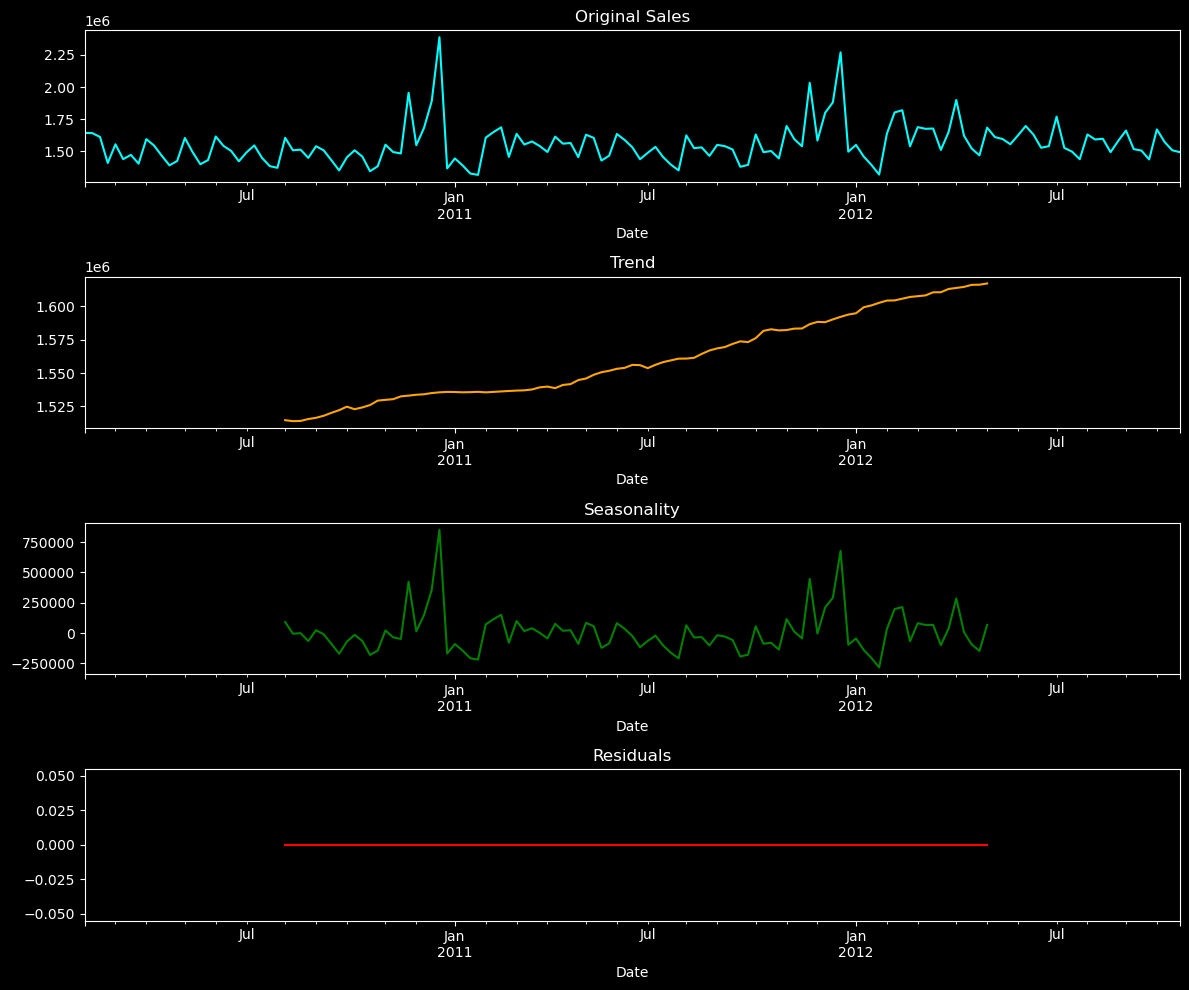

In [18]:
fig, axes =plt.subplots(4,1, figsize=(12,10))

store1['Weekly_Sales'].plot(ax=axes[0],title='Original Sales', color='cyan')
store1['Trend'].plot(ax=axes[1], title='Trend', color='orange')
store1['seasonality'].plot(ax=axes[2], title='Seasonality', color='green')
store1['residual'].plot(ax=axes[3], title='Residuals', color='red')
plt.tight_layout()
plt.show()

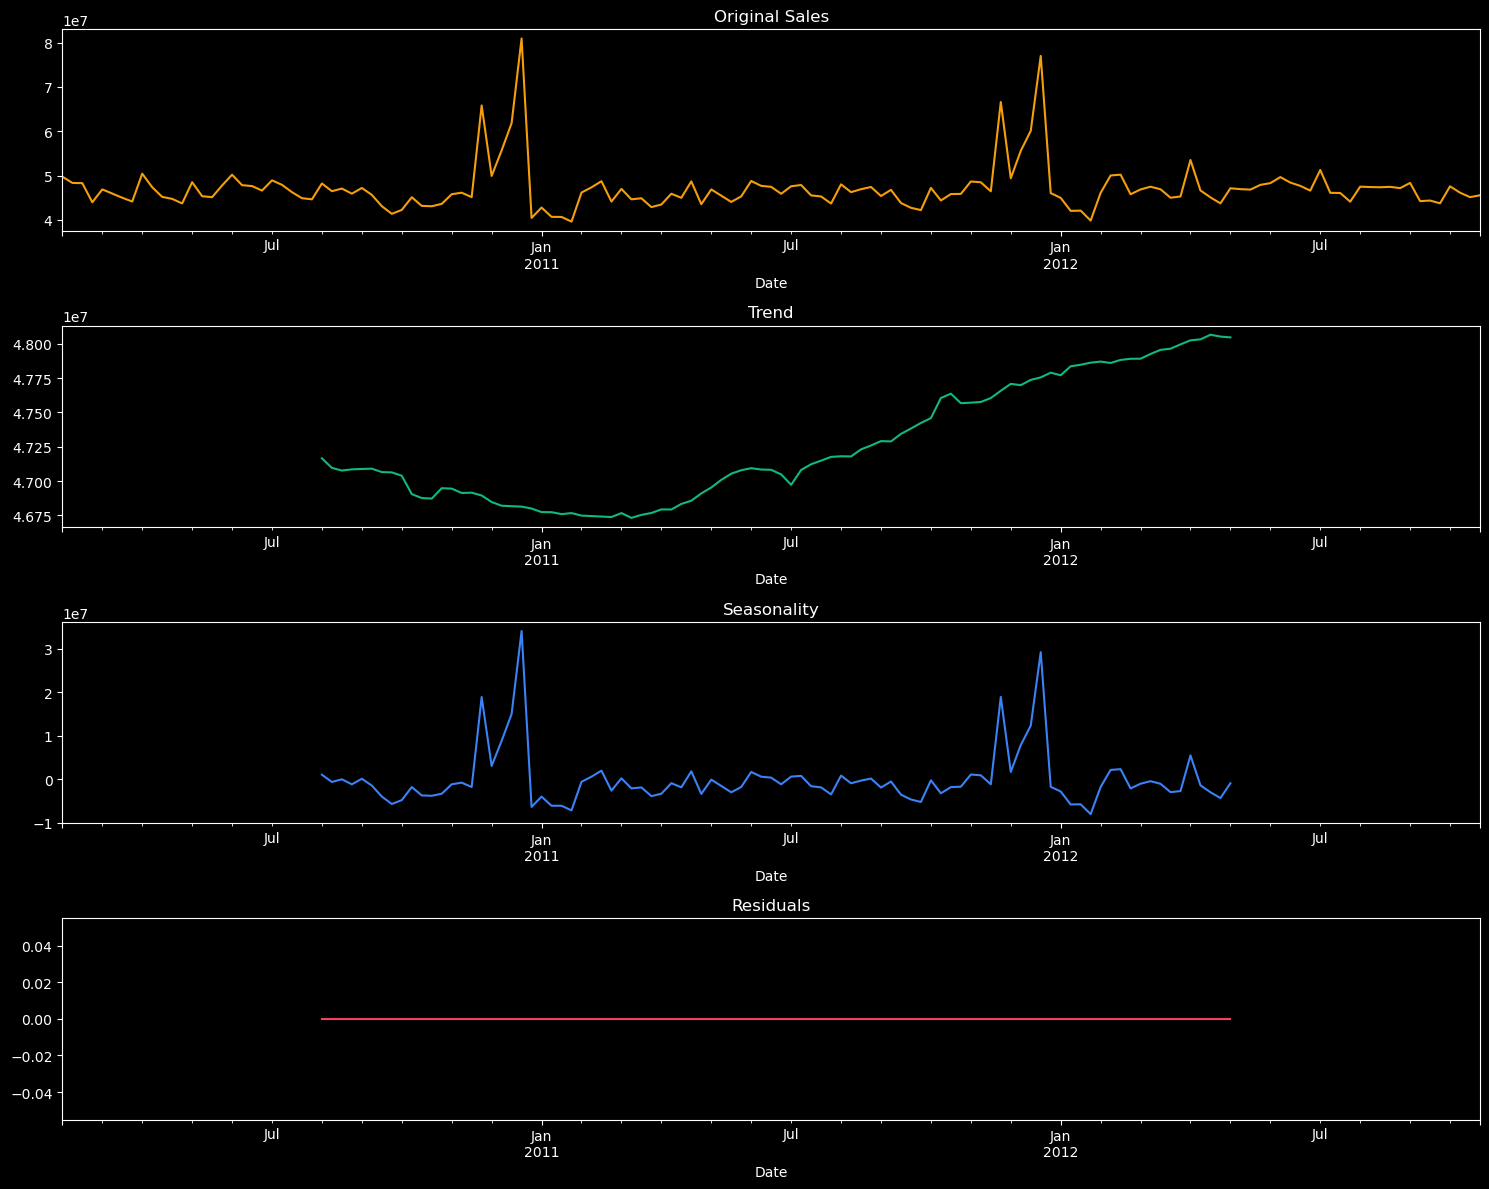

In [19]:

all_stores = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
all_stores.set_index('Date', inplace=True)

# Trend
all_stores['Trend'] = all_stores['Weekly_Sales'].rolling(window=52, center=True).mean()

# Seasonality
all_stores['Seasonality'] = all_stores['Weekly_Sales'] - all_stores['Trend']

# Residual
all_stores['Residual'] = all_stores['Weekly_Sales'] - all_stores['Trend'] - all_stores['Seasonality']

# Plot
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

all_stores['Weekly_Sales'].plot(ax=axes[0], color='#f59e0b', title='Original Sales')
all_stores['Trend'].plot(ax=axes[1], color='#10b981', title='Trend')
all_stores['Seasonality'].plot(ax=axes[2], color='#3b82f6', title='Seasonality')
all_stores['Residual'].plot(ax=axes[3], color='#f43f5e', title='Residuals')

plt.tight_layout()
plt.show()

Forcasting

In [20]:
ts =df.groupby('Date')['Weekly_Sales'].sum().reset_index()
ts.set_index('Date', inplace=True)

train_size=int(len(ts)*0.8)
train=ts[:train_size]
test=ts[train_size:]

print('train size:', len(train))
print('test size:', len(test))



train size: 114
test size: 29


In [21]:
window=4
test['SMA']=ts['Weekly_Sales'].rolling(window=window).mean().shift(1).iloc[train_size:]

weights=np.array([1,2,3,4])

def wma(series,w):
    return series.rolling(window=len(w)).apply(lambda x: np.dot(x,w)/w.sum(), raw=True)

test['WMA']=wma(ts['Weekly_Sales'], weights).shift(1).iloc[train_size:]

test['EMA']=ts['Weekly_Sales'].ewm(span=window, adjust=False).mean().shift(1).iloc[train_size:]

print('done')
test.head()


done


C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\761608519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['SMA']=ts['Weekly_Sales'].rolling(window=window).mean().shift(1).iloc[train_size:]
C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\761608519.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['WMA']=wma(ts['Weekly_Sales'], weights).shift(1).iloc[train_size:]
C:\Users\mohamed\AppData\Local\Temp\ipykernel_16348\761608519.py:11: SettingWithCopyWarning: 
A value is trying to be set on

,Weekly_Sales,SMA,WMA,EMA
Date,,,,
2012-04-13,46629261.41,4.766762e+07,4.867169e+07,4.891710e+07
2012-04-20,45072529.78,4.759956e+07,4.825635e+07,4.800197e+07
2012-04-27,43716798.89,4.761924e+07,4.724554e+07,4.683019e+07
2012-05-04,47124197.93,4.723023e+07,4.568456e+07,4.558483e+07
2012-05-11,46925878.99,4.563570e+07,4.564215e+07,4.620058e+07


In [22]:
def mea(actual, predicted):
    return np.mean(np.abs(actual - predicted))
mae_sma=mea(test['Weekly_Sales'], test['SMA'])
mae_wma=mea(test['Weekly_Sales'], test['WMA'])
mae_ema=mea(test['Weekly_Sales'], test['EMA'])

print(f'MAE SMA: {mae_sma:.2f}')
print(f'MAE WMA: {mae_wma:.2f}')
print(f'MAE EMA: {mae_ema:.2f}')

best=min(mae_sma, mae_wma, mae_ema)
print(f'Best method: {"SMA" if best==mae_sma else "WMA" if best==mae_wma else "EMA"} with MAE: {best:.2f}')

MAE SMA: 1591869.67
MAE WMA: 1654907.30
MAE EMA: 1541240.61
Best method: EMA with MAE: 1541240.61


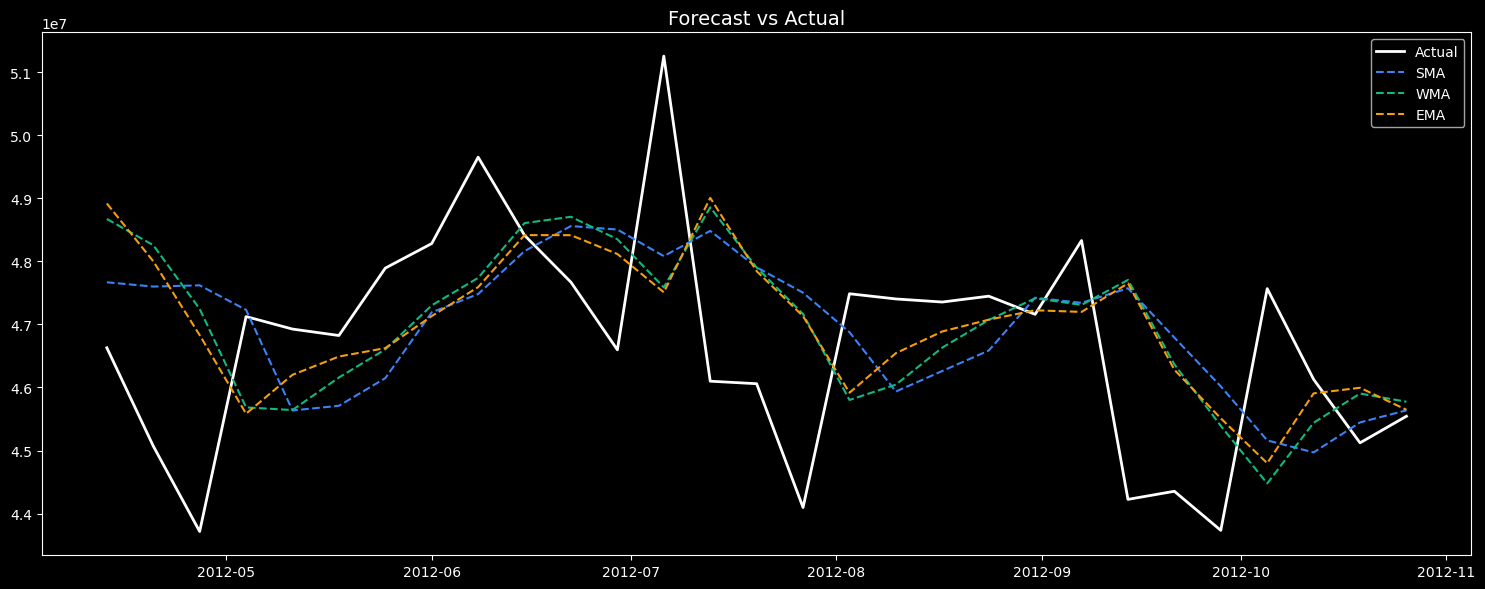

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(test.index, test['Weekly_Sales'], color='white', label='Actual', linewidth=2)
plt.plot(test.index, test['SMA'], color='#3b82f6', label='SMA', linestyle='--')
plt.plot(test.index, test['WMA'], color='#10b981', label='WMA', linestyle='--')
plt.plot(test.index, test['EMA'], color='#f59e0b', label='EMA', linestyle='--')
plt.title('Forecast vs Actual', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"SMA MAPE: {mape(test['Weekly_Sales'], test['SMA']):.2f}%")
print(f"WMA MAPE: {mape(test['Weekly_Sales'], test['WMA']):.2f}%")
print(f"EMA MAPE: {mape(test['Weekly_Sales'], test['EMA']):.2f}%")

SMA MAPE: 3.44%
WMA MAPE: 3.57%
EMA MAPE: 3.32%
